In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# First lets do the time series forecast using the prophet

In [4]:
df = pd.read_csv('/content/GE.csv')

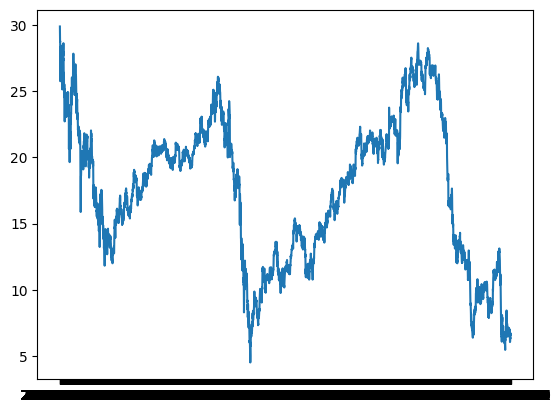

In [5]:
plt.plot(df['Date'],df['Close(t)'])
plt.show()

In [6]:
df['Close(t)'].isnull().sum()

np.int64(0)

In [7]:
df_new = df[['Date','Close(t)']]

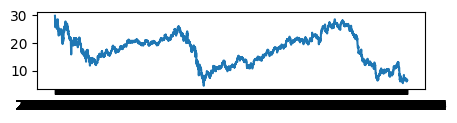

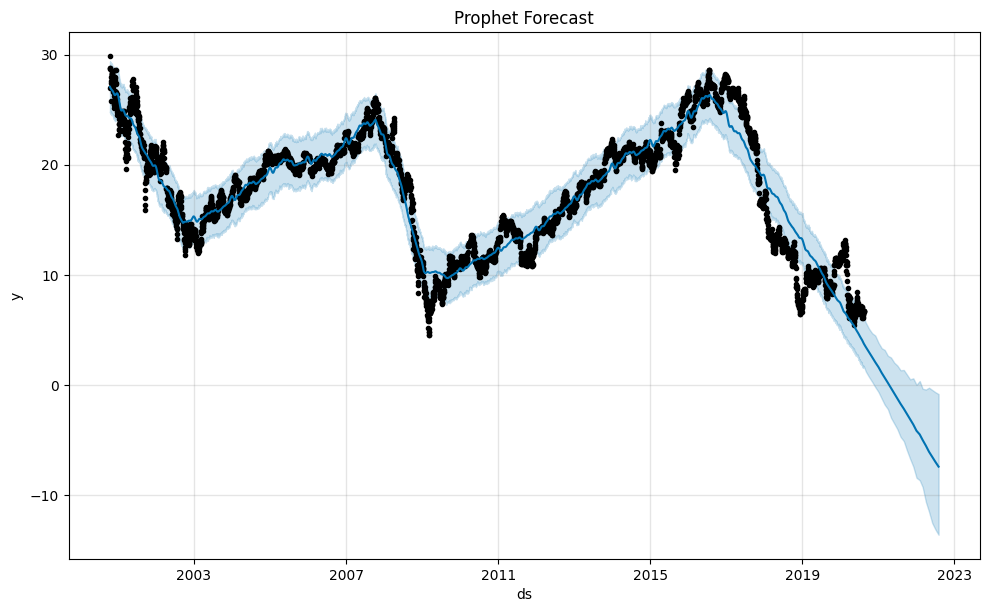

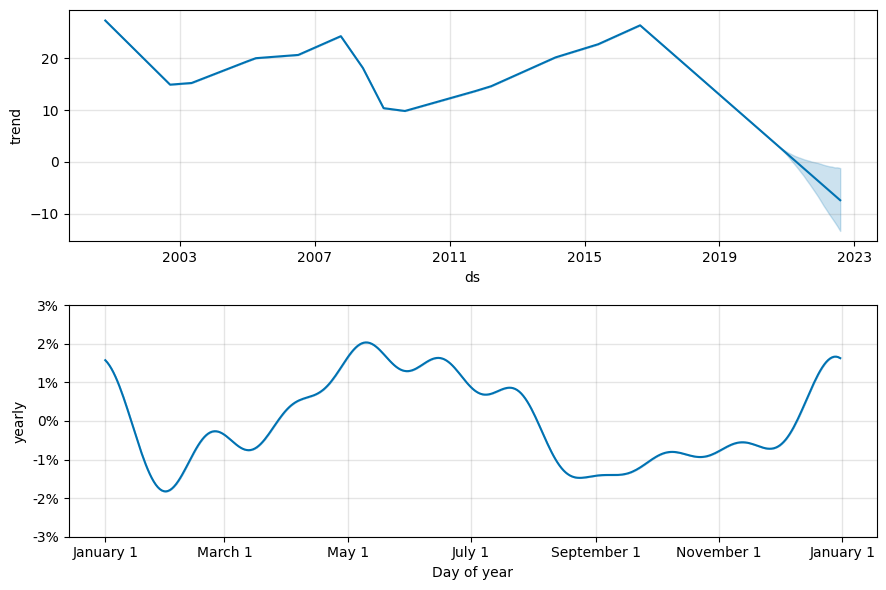

INFO:prophet:Making 9 forecasts with cutoffs between 2011-08-16 00:00:00 and 2019-08-14 00:00:00


  0%|          | 0/9 [00:00<?, ?it/s]

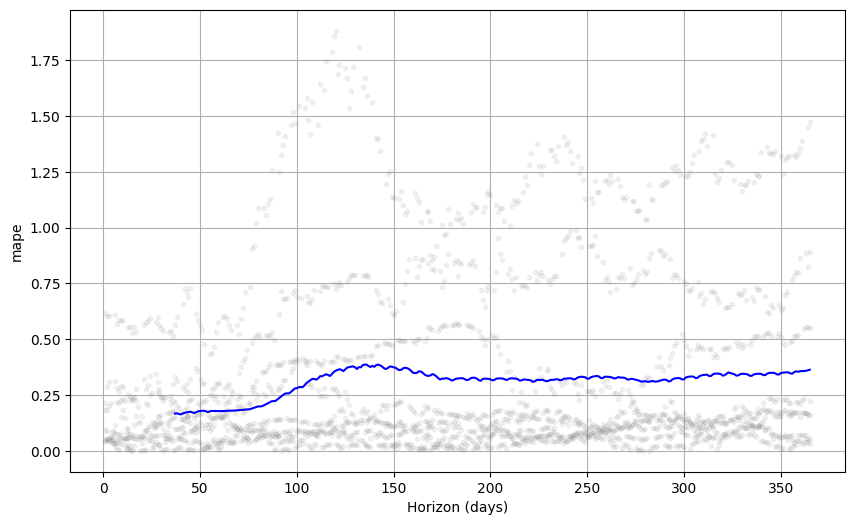

  horizon        mse      rmse       mae      mape     mdape     smape  \
0 37 days  10.521183  3.243637  2.506141  0.167001  0.098041  0.147014   
1 38 days  10.600063  3.255774  2.518934  0.167807  0.102234  0.147596   
2 39 days  10.445356  3.231928  2.498532  0.165397  0.100045  0.145708   
3 40 days  10.176182  3.190013  2.461398  0.162787  0.100045  0.143958   
4 41 days  10.415749  3.227344  2.498086  0.167000  0.106531  0.147420   

   coverage  
0  0.417193  
1  0.414665  
2  0.414454  
3  0.418584  
4  0.411504  


In [8]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')



df_new.columns = ['ds','y']



plt.figure(figsize=(5,1))
plt.plot(df_new['ds'], df_new['y'])

plt.show()

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)



m.fit(df_new)


future = m.make_future_dataframe(periods=24, freq='MS')
forecast = m.predict(future)

m.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

m.plot_components(forecast)
plt.show()


df_cv = cross_validation(
    m,
    initial='3650 days',
    period='365 days',
    horizon='365 days'
)

df_p = performance_metrics(df_cv)

plot_cross_validation_metric(df_cv, metric='mape')
plt.show()

print(df_p.head())


In [30]:
rmse_prophet = df_p['rmse'].mean()

In [9]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [10]:
df = pd.read_csv('/content/GE.csv')

In [11]:
df

,Date,Open,High,Low,Close(t),Volume,SD20,Upper_Band,Lower_Band,S_Close(t-1),...,QQQ_MA10,QQQ_MA20,QQQ_MA50,SnP_Close,SnP(t-1)),SnP(t-5),DJIA_Close,DJIA(t-1)),DJIA(t-5),Close_forcast
0,2000-10-16,29.49,29.94,29.29,29.87,13513900,0.675586,31.263173,28.560827,29.49,...,71.051,74.9815,79.7930,1374.62,1374.17,1402.03,10238.80,10192.18,10568.43,28.77
1,2000-10-17,29.84,29.84,28.42,28.77,17530200,0.714986,31.309472,28.449528,29.87,...,70.550,74.3305,79.5488,1349.97,1374.62,1387.02,10089.71,10238.80,10524.40,28.71
2,2000-10-18,27.80,28.87,27.35,28.71,19151700,0.748074,31.350148,28.357852,28.77,...,69.885,73.6055,79.2676,1342.13,1349.97,1364.59,9975.02,10089.71,10413.79,28.77
3,2000-10-19,28.71,28.94,28.32,28.77,13716500,0.765210,31.371420,28.310580,28.71,...,69.814,73.4885,79.1532,1388.76,1342.13,1329.78,10142.98,9975.02,10034.58,26.96
4,2000-10-20,28.32,28.58,26.71,26.96,18720100,1.000374,31.710747,27.709253,28.77,...,70.103,73.1995,79.0922,1396.93,1388.76,1374.17,10226.59,10142.98,10192.18,25.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,2020-08-07,6.29,6.46,6.25,6.40,83026200,0.363499,7.407497,5.953503,6.33,...,266.054,263.4085,252.2098,3351.28,3349.16,3271.12,27433.48,27386.98,26428.32,6.67
4984,2020-08-10,6.43,6.70,6.38,6.67,94345000,0.363476,7.405952,5.952048,6.40,...,267.073,263.9970,252.9570,3360.47,3351.28,3294.61,27791.44,27433.48,26664.40,6.73
4985,2020-08-11,6.87,7.00,6.69,6.73,93141500,0.360647,7.392793,5.950207,6.67,...,267.911,264.2380,253.5878,3333.69,3360.47,3306.51,27686.91,27791.44,26828.47,6.72
4986,2020-08-12,6.87,6.88,6.58,6.72,70186500,0.343764,7.338027,5.962973,6.73,...,269.120,264.7860,254.3206,3380.35,3333.69,3327.77,27976.84,27686.91,27201.52,6.60


In [12]:
df_arima = df[['Date','Close(t)']]

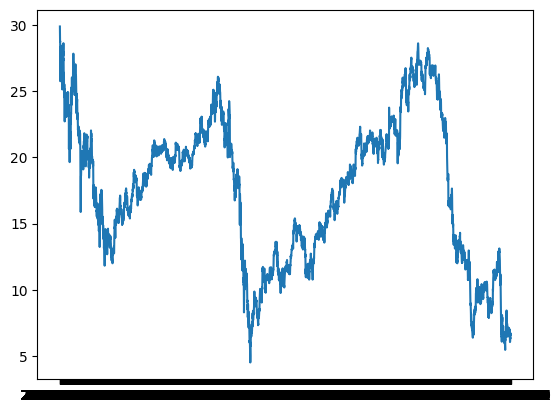

In [13]:
plt.plot(df_arima['Date'],df_arima['Close(t)'])

In [14]:
print(df_arima)

            Date  Close(t)
0     2000-10-16     29.87
1     2000-10-17     28.77
2     2000-10-18     28.71
3     2000-10-19     28.77
4     2000-10-20     26.96
...          ...       ...
4983  2020-08-07      6.40
4984  2020-08-10      6.67
4985  2020-08-11      6.73
4986  2020-08-12      6.72
4987  2020-08-13      6.60

[4988 rows x 2 columns]


In [15]:
df_arima.set_index('Date', inplace=True)


In [16]:
train_size = int(len(df_arima) * 0.8)

train = df_arima.iloc[:train_size]
test = df_arima.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 3990
Test size: 998


In [17]:
from pmdarima import auto_arima

auto_model = auto_arima(train,
                        seasonal = True,
                        m = 12,
                        trace = True)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2016.636, Time=13.26 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2023.150, Time=0.22 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2018.827, Time=1.19 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2018.661, Time=1.45 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2021.170, Time=0.15 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=2015.889, Time=10.35 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=2016.040, Time=4.46 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=2015.813, Time=27.50 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=2017.959, Time=31.72 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=2017.482, Time=4.76 sec
 ARIMA(2,1,1)(0,0,2)[12] intercept   : AIC=2017.457, Time=6.63 sec
 ARIMA(3,1,2)(0,0,2)[12] intercept   : AIC=2021.430, Time=17.88 sec
 ARIMA(2,1,3)(0,0,2)[12] intercept   : AIC=2002.391, Time=39.52 sec
 ARIMA(2,1,3)(0,0,1)[12] intercept   : AIC=2005.673, Time=13.44 sec
 ARIMA(2,1,3

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


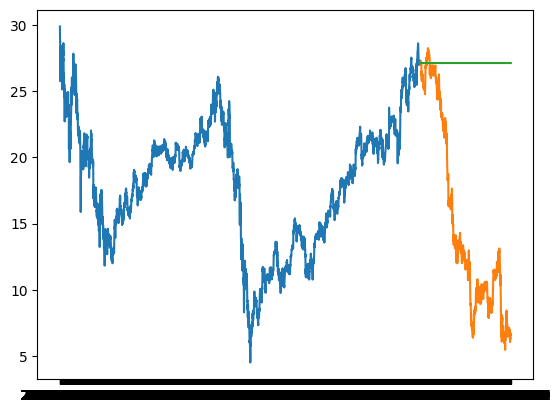

mae 12.143224331807529
mse 197.3476388968155
rmse 14.048047511907678
aic 2008.3652294134577
bic 2046.1130045248901


In [24]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error,mean_squared_error

model = ARIMA(train,order = (2,1,3))

result = model.fit()

forecast  = result.get_forecast(steps = len(test))
mean_forecast = forecast.predicted_mean

plt.plot(train['Close(t)'],label = 'train')
plt.plot(test['Close(t)'],label = 'test')
plt.plot(test.index,mean_forecast , label = 'forecast')
plt.show()

rmse_arima = np.sqrt(mean_squared_error(test,mean_forecast))
print('mae',mean_absolute_error(test,mean_forecast))
print('mse',mean_squared_error(test,mean_forecast))
print('rmse',np.sqrt(mean_squared_error(test,mean_forecast)))
print('aic',result.aic)
print('bic',result.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


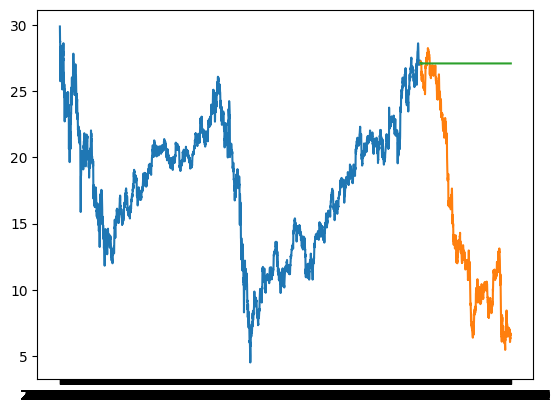

mae 12.114484138746185
mse 196.58731556803357
rmse 14.020959866144457
aic 2000.4080430510198
bic 2050.7384098662633


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order = (2,1,3),
                seasonal_order = (0,0,2,12),
                seasonal_period = 12)

results = model.fit()

forecast = results.forecast(steps = len(test))

plt.plot(train,label = 'train')
plt.plot(test,label = 'test')
plt.plot(test.index,forecast,label = 'forecast')
plt.show()

rmse_sarima = np.sqrt(mean_squared_error(test,forecast))

print('mae',mean_absolute_error(test,forecast))
print('mse',mean_squared_error(test,forecast))
print('rmse',np.sqrt(mean_squared_error(test,forecast)))
print('aic',results.aic)
print('bic',results.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


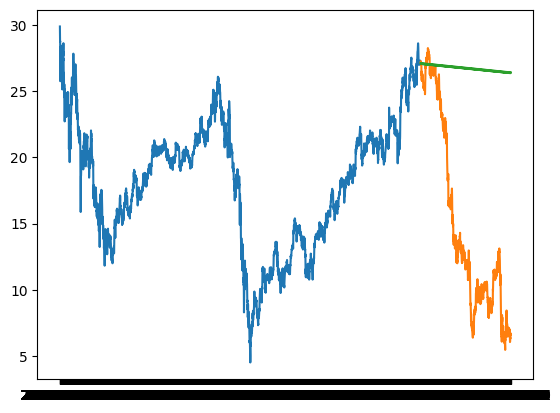

mae 11.761953182687083
mse 185.51158030977237
rmse 13.62026359178751
aic -9284.442481447817
bic -9183.777737289674


In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train,
                                trend = 'add',
                                seasonal = 'add',
                                seasonal_periods = 12)

result_es = model_es.fit()

forecast = result_es.forecast(steps = len(test))

plt.plot(train,label = 'train')
plt.plot(test,label = 'test')
plt.plot(test.index,forecast,label = 'forecast')
plt.show()

rmse_exponent = np.sqrt(mean_squared_error(test,forecast))
print('mae',mean_absolute_error(test,forecast))
print('mse',mean_squared_error(test,forecast))
print('rmse',np.sqrt(mean_squared_error(test,forecast)))
print('aic',result_es.aic)
print('bic',result_es.bic)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1828 - val_loss: 0.0627
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0319 - val_loss: 0.0723
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0256 - val_loss: 0.0395
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0220 - val_loss: 0.0267
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0223 - val_loss: 0.0379
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0215 - val_loss: 0.0401
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0201 - val_loss: 0.0155
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0177 - val_loss: 0.0435
Epoch 9/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0177 - val_loss: 0.0139
Epoch 10/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0173 - val_loss: 0.0148
Epoch 11/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0176 - val_loss: 0.0143
Epoch 12/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 

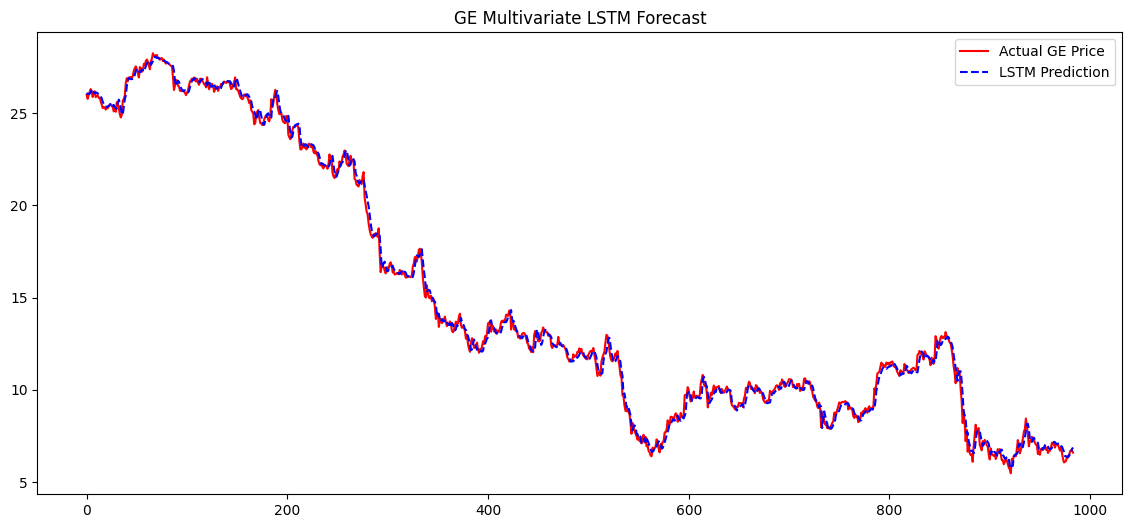

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load and Select Multivariate Features
df = pd.read_csv('/content/GE.csv')
# We place the target 'Close(t)' at index 0 for easier inverse scaling later
cols = ['Close(t)', 'Open', 'High', 'Low', 'Volume']
df_selected = df[cols].astype(float)

# 2. Chronological Split (80% Train, 20% Test)
train_size = int(len(df_selected) * 0.8)
train_df = df_selected[:train_size]
test_df = df_selected[train_size:]

# 3. Scaling (Prevent Leakage by fitting only on Train)
scaler = StandardScaler()
scaler = scaler.fit(train_df)
train_scaled = scaler.transform(train_df)
test_scaled = scaler.transform(test_df)

# 4. Create Windowed Sequences
def create_sequences(data, n_past=14, n_future=1):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, 0:data.shape[1]])
        y.append(data[i + n_future - 1:i + n_future, 0])
    return np.array(X), np.array(y)

trainX, trainY = create_sequences(train_scaled)
testX, testY = create_sequences(test_scaled)

# 5. Build Multivariate LSTM Model
model = Sequential([
    Input(shape=(trainX.shape[1], trainX.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(trainY.shape[1])
])

model.compile(optimizer='adam', loss='mse')

# 6. Fit with Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(trainX, trainY, epochs=50, batch_size=32,
                    validation_split=0.1, callbacks=[early_stop], verbose=1)

# 7. Predict and Inverse Transform
prediction = model.predict(testX)

# Padding prediction with dummy values to match scaler's 5-column input
prediction_copies = np.repeat(prediction, df_selected.shape[1], axis=-1)
y_pred = scaler.inverse_transform(prediction_copies)[:, 0]

# Same for actual values
testY_copies = np.repeat(testY, df_selected.shape[1], axis=-1)
y_actual = scaler.inverse_transform(testY_copies)[:, 0]

# 8. Visualization
plt.figure(figsize=(14, 6))
plt.plot(y_actual, color='red', label='Actual GE Price')
plt.plot(y_pred, color='blue', linestyle='--', label='LSTM Prediction')
plt.title('GE Multivariate LSTM Forecast')
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_lstm = np.sqrt(mean_squared_error(y_actual,y_pred))



In [32]:
print('rmse_prophet:', rmse_prophet)
print('rmse_arima:',rmse_arima)
print('rmse_sarima:',rmse_sarima)
print('rmse_expo:',rmse_exponent)
print('rmse_lstm:',rmse_lstm)

rmse_prophet: 5.612309822317333
rmse_arima: 14.048047511907678
rmse_sarima: 14.020959866144457
rmse_expo: 13.62026359178751
rmse_lstm: 0.3402763638395057


By the above results we can understand that lstm is the best model and then the prophet is the second best model. So in case if we are using in the real life then it is better to use the lstm rather than using the other models.